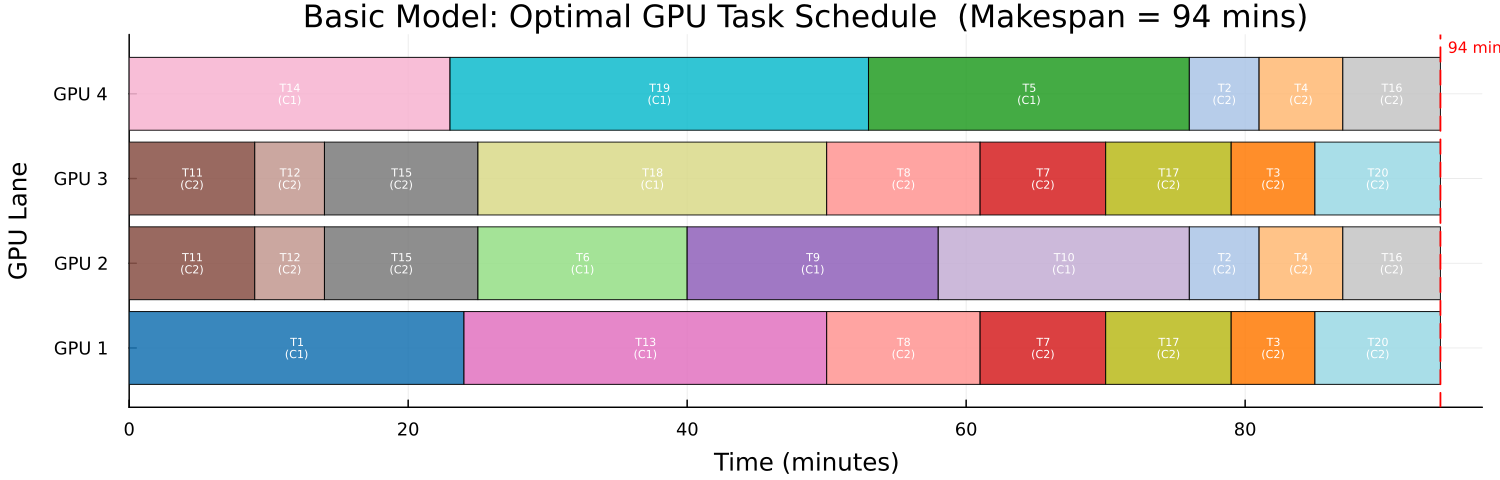

In [4]:

# Visualize the basic model schedule as a Gantt chart
# Schedule from the solved basic model:
#   (task_id, config_k, start_time, finish_time)
using Plots

raw_schedule = [
    (1,  1,  0, 24),
    (2,  2, 76, 81),
    (3,  2, 79, 85),
    (4,  2, 81, 87),
    (5,  1, 53, 76),
    (6,  1, 25, 40),
    (7,  2, 61, 70),
    (8,  2, 50, 61),
    (9,  1, 40, 58),
    (10, 1, 58, 76),
    (11, 2,  0,  9),
    (12, 2,  9, 14),
    (13, 1, 24, 50),
    (14, 1,  0, 23),
    (15, 2, 14, 25),
    (16, 2, 87, 94),
    (17, 2, 70, 79),
    (18, 1, 25, 50),
    (19, 1, 23, 53),
    (20, 2, 85, 94),
]

# gpus_needed: config 1 → 1 GPU, config 2 → 2 GPUs
schedule = [(id, k, s, f, k == 1 ? 1 : 2) for (id, k, s, f) in raw_schedule]
sort!(schedule, by = s -> s[3])  # sort by start time

# Greedy GPU lane assignment:
# For each task (earliest-start first), assign the lowest free lane(s).
# For multi-GPU tasks, prefer consecutive lanes to keep the chart readable;
# fall back to any free lanes if no consecutive block is available.
G_total = 4
gpu_free_at = zeros(Int, G_total)
task_lanes = Dict{Int, Vector{Int}}()

for (task_id, config, start, finish, gpus_needed) in schedule
    assigned = Int[]
    if gpus_needed == 1
        # pick the lowest single free lane
        free = sort(findall(t -> t <= start, gpu_free_at))
        assigned = free[1:1]
    else
        # try to find gpus_needed consecutive free lanes
        for start_lane in 1:(G_total - gpus_needed + 1)
            candidate = collect(start_lane : start_lane + gpus_needed - 1)
            if all(gpu_free_at[l] <= start for l in candidate)
                assigned = candidate
                break
            end
        end
        # fallback: use any free lanes (non-consecutive)
        if isempty(assigned)
            free = sort(findall(t -> t <= start, gpu_free_at))
            assigned = free[1:gpus_needed]
        end
    end
    task_lanes[task_id] = assigned
    for lane in assigned
        gpu_free_at[lane] = finish
    end
end

colors = palette(:tab20, 20)

plt = plot(
    xlims = (0, 97),
    ylims = (0.3, G_total + 0.7),
    xlabel = "Time (minutes)",
    ylabel = "GPU Lane",
    title  = "Basic Model: Optimal GPU Task Schedule  (Makespan = 94 mins)",
    yticks = (1:G_total, ["GPU $i" for i in 1:G_total]),
    legend = false,
    size   = (1000, 320),
    dpi    = 150,
    left_margin   = 5Plots.mm,
    bottom_margin = 5Plots.mm,
)

# Draw ONE rectangle per assigned lane to avoid spanning across occupied lanes
for (task_id, config, start, finish, gpus_needed) in schedule
    lanes = task_lanes[task_id]
    mid_t = (start + finish) / 2.0
    for lane in lanes
        y_lo = lane - 0.43
        y_hi = lane + 0.43
        rect = Shape(
            [start, finish, finish, start, start],
            [y_lo,  y_lo,  y_hi,  y_hi,  y_lo],
        )
        plot!(plt, rect,
              fillcolor = colors[task_id],
              linecolor = :black,
              linewidth = 0.7,
              alpha     = 0.88)
        annotate!(plt, mid_t, lane, text("T$(task_id)\n(C$(config))", 5, :center, :white))
    end
end

# dashed vertical line at makespan
vline!(plt, [94], color = :red, linestyle = :dash, linewidth = 1.2)
annotate!(plt, 94.6, G_total + 0.55, text("94 min", 7, :left, :red))

savefig(plt, "fig_basic_gantt.png")
display(plt)


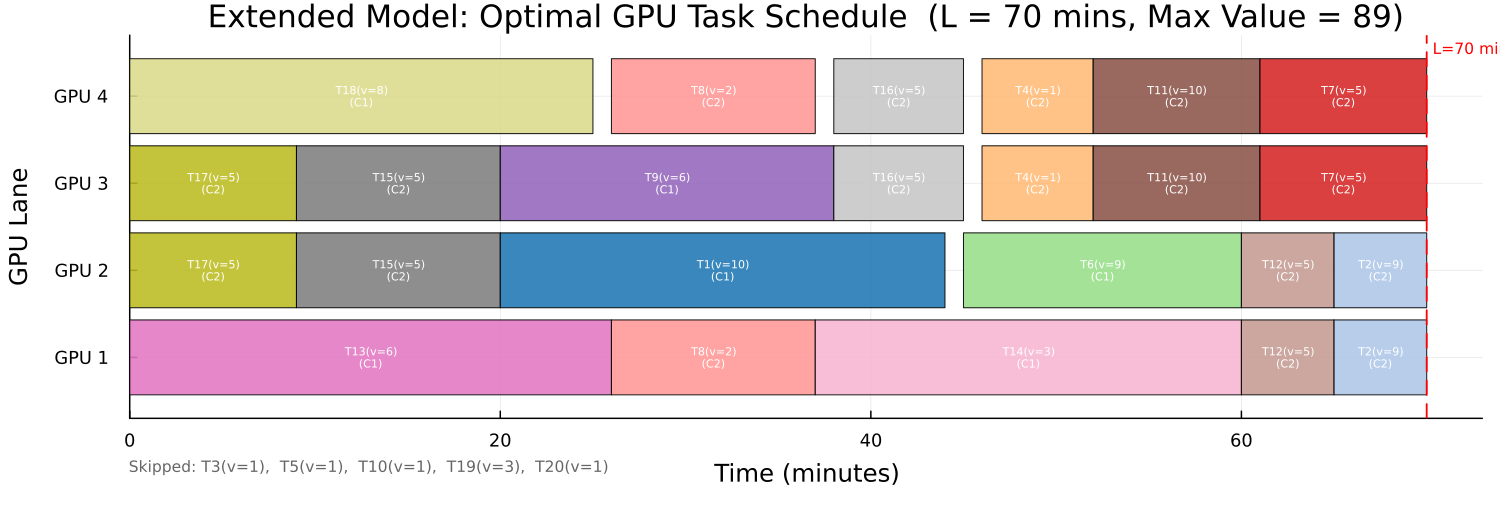

In [7]:

# Visualize the extended model schedule as a Gantt chart
# Some tasks are skipped; skipped tasks are listed below the chart.
using Plots

# (task_id, config_k, start_time, finish_time, value) -- only executed tasks
executed_schedule = [
    (1,  1, 20, 44, 10),
    (2,  2, 65, 70,  9),
    (4,  2, 46, 52,  1),
    (6,  1, 45, 60,  9),
    (7,  2, 61, 70,  5),
    (8,  2, 26, 37,  2),
    (9,  1, 20, 38,  6),
    (11, 2, 52, 61, 10),
    (12, 2, 60, 65,  5),
    (13, 1,  0, 26,  6),
    (14, 1, 37, 60,  3),
    (15, 2,  9, 20,  5),
    (16, 2, 38, 45,  5),
    (17, 2,  0,  9,  5),
    (18, 1,  0, 25,  8),
]

# (task_id, value) -- only skipped tasks
skipped_tasks = [(3,1), (5,1), (10,1), (19,3), (20,1)]

L = 70   # time limit

# gpus_needed: config 1 → 1 GPU, config 2 → 2 GPUs
schedule = [(id, k, s, f, v, k == 1 ? 1 : 2) for (id, k, s, f, v) in executed_schedule]
sort!(schedule, by = s -> s[3])

# Greedy GPU lane assignment (consecutive lanes preferred)
G_total = 4
gpu_free_at = zeros(Int, G_total)
task_lanes = Dict{Int, Vector{Int}}()

for (task_id, config, start, finish, val, gpus_needed) in schedule
    assigned = Int[]
    if gpus_needed == 1
        free = sort(findall(t -> t <= start, gpu_free_at))
        assigned = free[1:1]
    else
        for start_lane in 1:(G_total - gpus_needed + 1)
            candidate = collect(start_lane : start_lane + gpus_needed - 1)
            if all(gpu_free_at[l] <= start for l in candidate)
                assigned = candidate
                break
            end
        end
        if isempty(assigned)
            free = sort(findall(t -> t <= start, gpu_free_at))
            assigned = free[1:gpus_needed]
        end
    end
    task_lanes[task_id] = assigned
    for lane in assigned
        gpu_free_at[lane] = finish
    end
end

colors = palette(:tab20, 20)

plt = plot(
    xlims = (0, 73),
    ylims = (0.3, G_total + 0.7),
    xlabel = "Time (minutes)",
    ylabel = "GPU Lane",
    title  = "Extended Model: Optimal GPU Task Schedule  (L = 70 mins, Max Value = 89)",
    yticks = (1:G_total, ["GPU $i" for i in 1:G_total]),
    legend = false,
    size   = (1000, 340),
    dpi    = 150,
    left_margin   = 5Plots.mm,
    bottom_margin = 8Plots.mm,
)

# Draw one rectangle per assigned lane
for (task_id, config, start, finish, val, gpus_needed) in schedule
    lanes = task_lanes[task_id]
    mid_t = (start + finish) / 2.0
    for lane in lanes
        y_lo = lane - 0.43
        y_hi = lane + 0.43
        rect = Shape(
            [start, finish, finish, start, start],
            [y_lo,  y_lo,  y_hi,  y_hi,  y_lo],
        )
        plot!(plt, rect,
              fillcolor = colors[task_id],
              linecolor = :black,
              linewidth = 0.7,
              alpha     = 0.88)
        annotate!(plt, mid_t, lane, text("T$(task_id)(v=$(val))\n(C$(config))", 5, :center, :white))
    end
end

# dashed vertical line at time limit
vline!(plt, [L], color = :red, linestyle = :dash, linewidth = 1.2)
annotate!(plt, L + 0.4, G_total + 0.55, text("L=$(L) min", 7, :left, :red))

# Annotate skipped tasks below the chart
skipped_str = "Skipped: " * join(["T$(id)(v=$(v))" for (id, v) in skipped_tasks], ",  ")
annotate!(plt, 0, -0.25, text(skipped_str, 7, :left, :gray40))

savefig(plt, "fig_extended_gantt.png")
display(plt)
